## HR Diagram
The Hertzsprung–Russell (HR) Diagram is a fundamental tool for understanding the life cycle and classification of stars. It plots stellar luminosity against surface temperature, revealing distinct groups such as the main sequence, giants, and white dwarfs.
In this exercise, we aim to generate an HR Diagram from a given dataset using Principal Component Analysis (PCA), a technique that seeks to explain the variance in the dataset through linear combinations of the original features.

In [16]:
import numpy as np
from matplotlib import pyplot as plt
path = 'C:/Users/alexv/Desktop/Università/astrostat/astrostatistics_bicocca_2025/solutions/'
from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
from astroML.stats import sigmaG
from scipy.stats import chi2
import scipy
from sklearn.preprocessing import StandardScaler
#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize = 10, usetex = True)


In [17]:
!pip install pandas
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\alexv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\alexv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
import pandas as pd
df_stars = pd.read_csv("stars.csv")
print(df_stars)
print(df_stars.shape)

     Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0               3068          0.002400        0.1700                   16.12   
1               3042          0.000500        0.1542                   16.60   
2               2600          0.000300        0.1020                   18.70   
3               2800          0.000200        0.1600                   16.65   
4               1939          0.000138        0.1030                   20.06   
..               ...               ...           ...                     ...   
235            38940     374830.000000     1356.0000                   -9.93   
236            30839     834042.000000     1194.0000                  -10.63   
237             8829     537493.000000     1423.0000                  -10.73   
238             9235     404940.000000     1112.0000                  -11.23   
239            37882     294903.000000     1783.0000                   -7.80   

       Star type Star color Spectral Cl

Loading data

In [19]:
from sklearn.preprocessing import LabelEncoder

#Encoding of colomuns
le_type = LabelEncoder()
df_stars['Star type'] = le_type.fit_transform(df_stars['Star type'])
print("classes star type:", le_type.classes_)
labels = le_type.inverse_transform(df_stars['Star type'])
le_color = LabelEncoder()
df_stars['Star color'] = le_color.fit_transform(df_stars['Star color'])
print("classi colori:", le_color.classes_)

le_spec = LabelEncoder()
df_stars['Spectral Class'] = le_spec.fit_transform(df_stars['Spectral Class'])
print("classi spettro:", le_spec.classes_)
print(df_stars['Spectral Class'])
#Select original columns(i.e Temperature, Luminosity, Radius)
numerical_cols = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']
X_numerical = df_stars[numerical_cols].values

X_categorical = df_stars[['Star type', 'Star color', 'Spectral Class']].values

# Stack together
data = np.hstack((X_numerical, X_categorical))
print(data)


classes star type: ['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']
classi colori: ['Blue' 'Blue ' 'Blue White' 'Blue white' 'Blue white ' 'Blue-White'
 'Blue-white' 'Orange' 'Orange-Red' 'Pale yellow orange' 'Red' 'White'
 'White-Yellow' 'Whitish' 'Yellowish' 'Yellowish White' 'white'
 'yellow-white' 'yellowish']
classi spettro: ['A' 'B' 'F' 'G' 'K' 'M' 'O']
0      5
1      5
2      5
3      5
4      5
      ..
235    6
236    6
237    0
238    0
239    6
Name: Spectral Class, Length: 240, dtype: int64
[[3.06800e+03 2.40000e-03 1.70000e-01 ... 0.00000e+00 1.00000e+01
  5.00000e+00]
 [3.04200e+03 5.00000e-04 1.54200e-01 ... 0.00000e+00 1.00000e+01
  5.00000e+00]
 [2.60000e+03 3.00000e-04 1.02000e-01 ... 0.00000e+00 1.00000e+01
  5.00000e+00]
 ...
 [8.82900e+03 5.37493e+05 1.42300e+03 ... 1.00000e+00 1.10000e+01
  0.00000e+00]
 [9.23500e+03 4.04940e+05 1.11200e+03 ... 1.00000e+00 1.10000e+01
  0.00000e+00]
 [3.78820e+04 2.94903e+05 1.78300e+03 ... 1.0

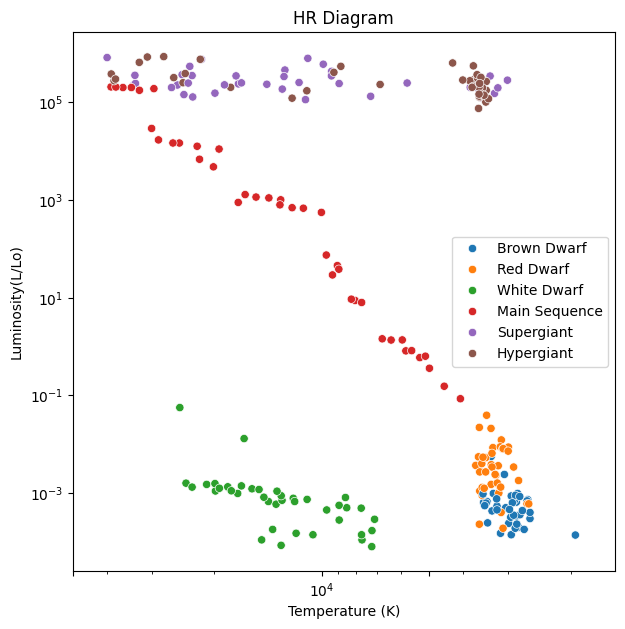

In [20]:
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)
plt.title("HR Diagram")
plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

Let's see if, without scaling the data, with PCA we can discern better the different class types.

In [21]:
from sklearn.decomposition import PCA
data = df_stars.drop(columns=["Star color", "Star type", "Spectral Class"])
data = np.array(data)
pca = PCA(n_components=2) 
pca.fit(data) 

eigenvalues = pca.transform(data) 
mean = pca.mean_ 
eigenvectors = pca.components_ 



print(eigenvalues.shape)
print(eigenvectors.shape)
evals = pca.explained_variance_ratio_ 

print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

(240, 2)
(2, 4)
Expained fractional variance of data encapsulated in the eigenvalues: [0.99760631 0.0023879 ]


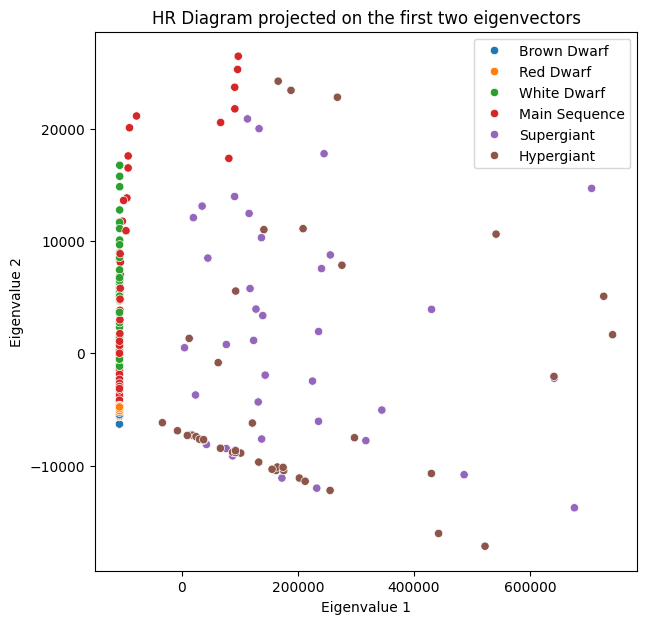

In [22]:
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=eigenvalues[:,0], y= eigenvalues[:,1], hue=labels)
plt.title("HR Diagram projected on the first two eigenvectors")
plt.xlabel("Eigenvalue 1")
plt.ylabel("Eigenvalue 2")
plt.show()

Now, before using PCA, we subtract the mean from the data and divide for its variance.

In [23]:
data_norm = StandardScaler().fit_transform(data)
print(data_norm.shape)

(240, 4)


(240, 4)
(4, 4)
Expained fractional variance of data encapsulated in the eigenvalues: [0.60357391 0.23500784 0.09329645 0.0681218 ]


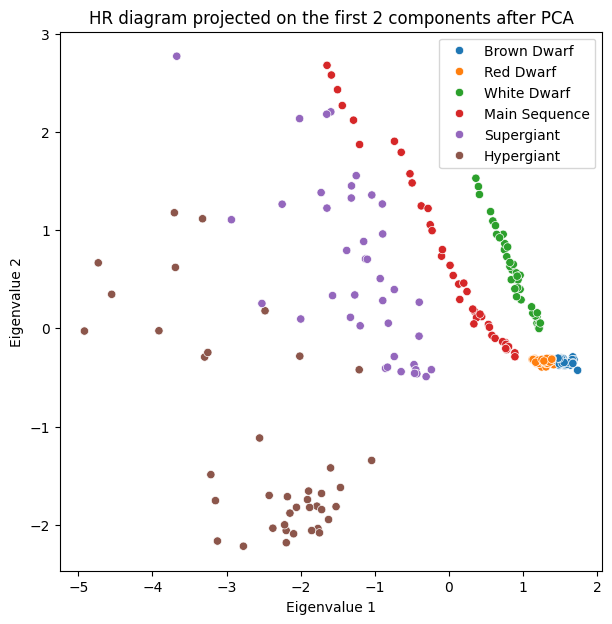

In [24]:
pca_norm = PCA()
pca_norm.fit(data_norm)
eigenvalues_n = pca_norm.transform(data_norm) 
mean = pca_norm.mean_ 
eigenvectors_n = pca_norm.components_ 

print(eigenvalues_n.shape)
print(eigenvectors_n.shape)
evals = pca_norm.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x= eigenvalues_n[:, 0], y=eigenvalues_n[:,1], hue=labels)
plt.title("HR diagram projected on the first 2 components after PCA")
plt.xlabel("Eigenvalue 1")
plt.ylabel("Eigenvalue 2")
plt.show()

Using only the first two principal components from PCA, we are able to explain 84% of the total variance in the dataset. Moreover, this transformation makes it easier to distinguish between different types of stars.